# Netflix Customer Churn & Engagement Analysis

## 📌 Context & Business Problem

Customer churn (subscriber attrition) is one of the most critical challenges facing global streaming platforms. Acquiring a new customer often costs 5 to 7 times more than retaining an existing one.

This dataset tracks user engagement, hardware utilization, billing mechanisms, and account inactivity to help data scientists and analysts uncover:

1. **Early Attrition Indicators**: What behavioral signals (e.g., login inactivity, declining watch hours) predict churn before it happens?
2. **Subscription Tier Viability**: How do churn rates differ between Basic ($8.99), Standard ($13.99), and Premium ($17.99) plans?
3. **Regional & Demographic Dynamics**: Which geographic markets and age cohorts represent the highest retention or attrition risk?
4. **Payment Gateway Friction**: Does payment method (e.g., Crypto, Gift Card vs Credit/Debit) impact customer lifetime value?

## 💡 Potential Tasks & Challenges for Kaggle Users
1. **Supervised Classification:**
    - Build and compare models (Logistic Regression, Random Forest, XGBoost, CatBoost, LightGBM) to classify subscriber churn (ROC-AUC, F1-Score, Precision-Recall).
2. **Feature Importance & Interpretability:**
    - Use SHAP (SHapley Additive exPlanations) to identify the driving factors behind churn decisions.
3. **Customer Segmentation & Clustering:**
    - Perform unsupervised clustering (K-Means, DBSCAN) using watch hours, daily streaming duration, and profile counts to identify distinct subscriber personas (e.g. "Binge Watchers", "Casual Viewers", "Dormant Accounts").
4. **Interactive Dashboarding:**
    - Explore and run the included Streamlit analytics app (streamlit_app.py) featuring full Power BI-style dark UX.

**Resolve all business problems and complete all tasks & challenges**

#### Import necessary libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set_theme()
%matplotlib inline

#### Load the dataset

In [3]:
path = "data/netflix_customer_churn.csv"
df = pd.read_csv(path)

#### Take a quick look at the Data

In [4]:
# First 10 rows of the data
df.head(10)

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action
5,d8079475-5be7-47e9-8782-ceb7ff61395e,58,Female,Standard,13.80,26,Oceania,Mobile,13.99,0,Debit Card,3,0.51,Action
6,8e63450a-13d6-4e83-bbb5-6aebde9152cb,48,Other,Basic,13.83,20,Asia,TV,8.99,0,Gift Card,5,0.66,Romance
7,02387681-8c42-462a-807a-de0168c73b38,51,Male,Basic,14.30,56,Europe,Mobile,8.99,1,Gift Card,1,0.25,Action
8,0bcaad0c-545c-4ee1-85a6-75e165f39361,45,Other,Basic,9.98,10,Asia,Mobile,8.99,0,PayPal,3,0.91,Romance
9,eae6439e-8cdf-4258-ab49-c493925b927a,32,Other,Premium,2.22,34,Europe,TV,17.99,1,Debit Card,1,0.06,Drama


In [5]:
# Last 10 rows of the data
df.tail(10)

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
4990,edb9036d-95f9-4998-9910-78ba85869dbd,57,Male,Standard,2.09,13,Asia,TV,13.99,1,Crypto,3,0.15,Romance
4991,ac6eb271-0239-4957-b828-c89508fcfbea,62,Male,Standard,7.31,26,Oceania,Desktop,13.99,0,Credit Card,2,0.27,Sci-Fi
4992,9721209e-3147-456f-a2c0-81d23b4cf822,34,Male,Standard,10.25,41,Oceania,Desktop,13.99,1,Crypto,3,0.24,Documentary
4993,f915a366-31c7-4a9e-9042-ca526c771219,23,Other,Standard,3.10,12,Europe,Laptop,13.99,1,Crypto,5,0.24,Comedy
4994,75532a22-9cd9-492c-8865-fa4ac7da2ec8,58,Other,Basic,10.90,22,Europe,TV,8.99,0,Credit Card,3,0.47,Action
4995,44f3ba44-b95d-4e50-a786-bac4d06f4a43,19,Female,Basic,49.17,11,Europe,Desktop,8.99,0,Credit Card,4,4.10,Drama
4996,18779bcb-ba2b-41da-b751-e70b812061ec,67,Female,Basic,9.24,2,North America,Desktop,8.99,0,PayPal,3,3.08,Documentary
4997,3f32e8c5-615b-4a3b-a864-db2688f7834f,66,Male,Standard,16.55,49,South America,Desktop,13.99,1,Debit Card,2,0.33,Action
4998,7b0ad82d-6571-430e-90f4-906259e0e89c,59,Female,Basic,9.12,3,Europe,Laptop,8.99,0,Credit Card,4,2.28,Sci-Fi
4999,82aeef39-ddb0-40ad-bae1-5c436e0cf042,57,Male,Basic,1.62,17,Africa,Mobile,8.99,1,Crypto,2,0.09,Action


In [6]:
# Information of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(7)
memor

In [7]:
df['gender'].value_counts()

gender
Female    1711
Male      1654
Other     1635
Name: count, dtype: int64

In [8]:
df['subscription_type'].value_counts()

subscription_type
Premium     1693
Basic       1661
Standard    1646
Name: count, dtype: int64

In [9]:
df['region'].value_counts()

region
South America    873
Europe           867
North America    851
Asia             841
Africa           803
Oceania          765
Name: count, dtype: int64

In [10]:
df['device'].value_counts()

device
Tablet     1048
Laptop     1006
Mobile     1004
TV          993
Desktop     949
Name: count, dtype: int64

In [11]:
df['churned'].value_counts()

churned
1    2515
0    2485
Name: count, dtype: int64

In [12]:
df['payment_method'].value_counts()

payment_method
Debit Card     1030
PayPal         1026
Crypto          995
Gift Card       976
Credit Card     973
Name: count, dtype: int64

In [13]:
df['favorite_genre'].value_counts()

favorite_genre
Drama          731
Documentary    729
Romance        725
Sci-Fi         720
Horror         713
Action         697
Comedy         685
Name: count, dtype: int64

In [14]:
# Description of the data
df.describe()

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.847400,11.649450,30.089800,13.683400,0.503000,3.024400,0.874800
std,15.501128,12.014654,17.536078,3.692062,0.500041,1.415841,2.619824
min,18.000000,0.010000,0.000000,8.990000,0.000000,1.000000,0.000000
25%,30.000000,3.337500,15.000000,8.990000,0.000000,2.000000,0.110000
50%,44.000000,8.000000,30.000000,13.990000,1.000000,3.000000,0.290000
75%,58.000000,16.030000,45.000000,17.990000,1.000000,4.000000,0.720000
max,70.000000,110.400000,60.000000,17.990000,1.000000,5.000000,98.420000


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'watch_hours'}>,
        <Axes: title={'center': 'last_login_days'}>],
       [<Axes: title={'center': 'monthly_fee'}>,
        <Axes: title={'center': 'churned'}>,
        <Axes: title={'center': 'number_of_profiles'}>],
       [<Axes: title={'center': 'avg_watch_time_per_day'}>, <Axes: >,
        <Axes: >]], dtype=object)

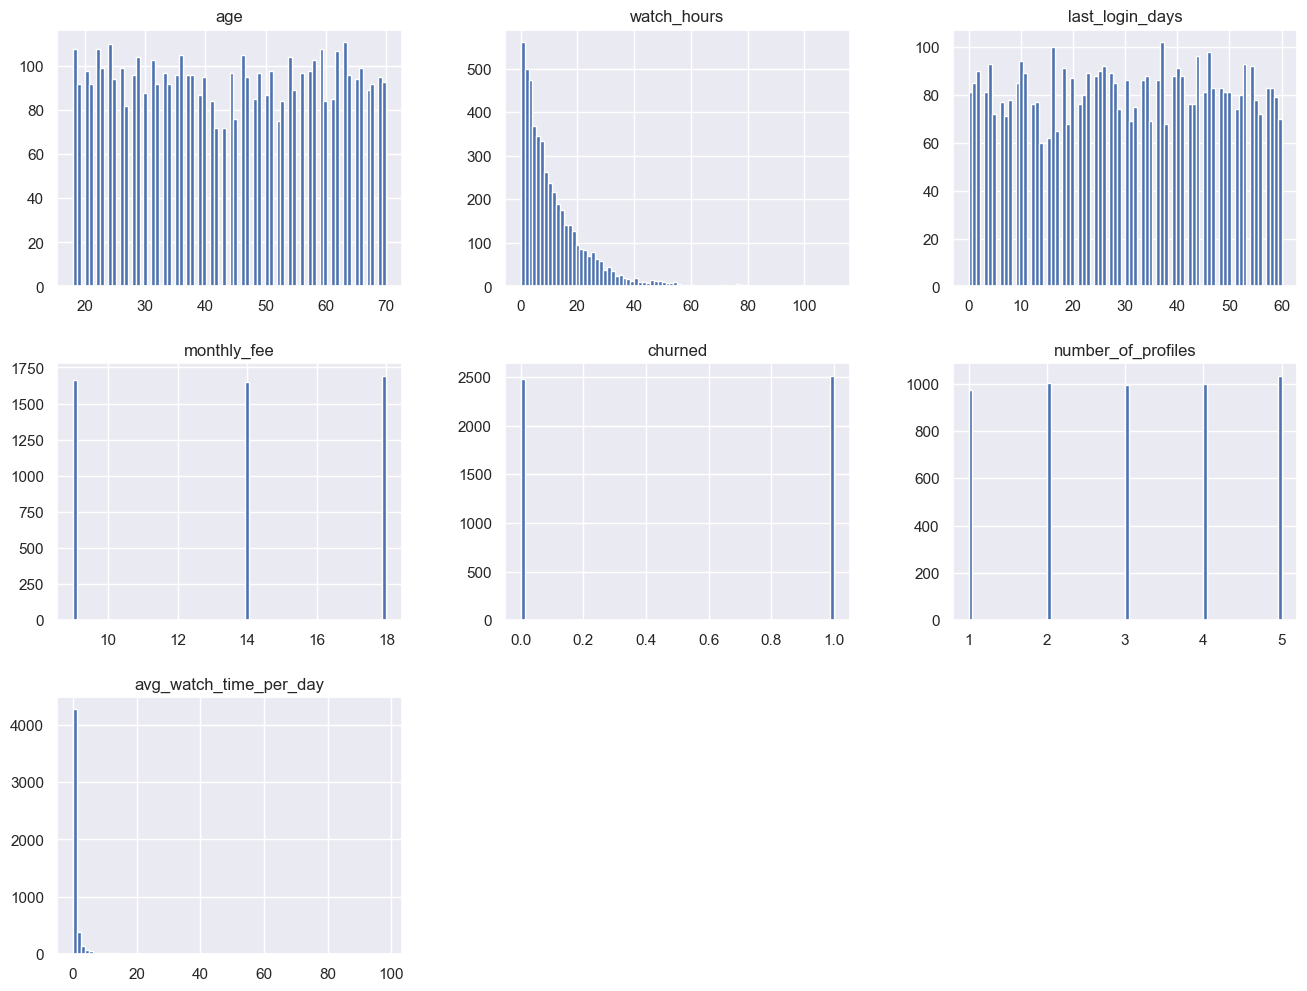

In [15]:
# Hist plot of the numerical features
df.hist(bins=80, figsize=(16,12))

#### 🔍 Initial Data Takeaways

Taking a quick look at the dataset, each row represents an individual user.

* **Target Variable:** `churned`
* **Numerical Features:** `age`, `watch_hours`, `last_login_days`, `number_of_profiles`, `avg_watch_time_per_day`
* **Categorical Features:** `gender`, `subscription_type`, `region`, `device`, `monthly_fee`, `payment_method`, `favorite_genre`
  > *Heads-up:* `subscription_type` and `monthly_fee` carry redundant information (they map 1:1).

---

#### Key Observations:
- **Missing Data:** Clean across the board—no null values to deal with.
- **Categorical Balance:** Classes are surprisingly well-balanced across categories (e.g., `gender` splits almost evenly: ~1,711 Female, ~1,654 Male, ~1,635 Other).
- **Distributions from Histograms:**
  - **Uniform:** `age`, `last_login_days`, and `number_of_profiles` show fairly flat/uniform distributions.
  - **Right-Skewed:** `watch_hours` and `avg_watch_time_per_day` have long tails to the right, which makes sense—most users watch moderately, while a small group clocks high hours.


#### Split the test set

In [16]:
# Structural Drop: `customer_id` and `monthly_fee`
X = df.drop(columns=['customer_id', 'monthly_fee'])
y = df['churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42, test_size=0.2)

Comparing `watch_hours` and `avg_watch_time_per_day` across the train and test sets. 

Because of the heavy right skew, we want to make sure the split didn't create an imbalance—our training set needs to stay representative of the overall distribution.

In [17]:
# Compare the `watch_hours` distribution
print("Train watch_hours:\n", X_train['watch_hours'].describe())
print("\nTest watch_hours:\n", X_test['watch_hours'].describe())

# Statistical test — check the distribution is the same or not
from scipy.stats import ks_2samp
stat, p_value = ks_2samp(X_train['watch_hours'], X_test['watch_hours'])
print(f"KS-test p-value: {p_value}")
# If p-value > 0.05 → distribution is the same (there is no significant difference)

Train watch_hours:
 count    4000.000000
mean       11.590895
std        11.780691
min         0.010000
25%         3.360000
50%         8.075000
75%        16.052500
max       101.060000
Name: watch_hours, dtype: float64

Test watch_hours:
 count    1000.000000
mean       11.883670
std        12.911751
min         0.050000
25%         3.160000
50%         7.640000
75%        15.880000
max       110.400000
Name: watch_hours, dtype: float64
KS-test p-value: 0.5749011372347846


In [18]:
# Apply the same to `avg_watch_time_per_day`
# Compare the `avg_watch_time_per_day` distribution
print("Train avg_watch_time_per_day:\n", X_train['avg_watch_time_per_day'].describe())
print("\nTest avg_watch_time_per_day:\n", X_test['avg_watch_time_per_day'].describe())

# Statistical test — check the distribution is the same or not
from scipy.stats import ks_2samp
stat, p_value = ks_2samp(X_train['avg_watch_time_per_day'], X_test['avg_watch_time_per_day'])
print(f"KS-test p-value: {p_value}")
# If p-value > 0.05 → distribution is the same (there is no significant difference)

Train avg_watch_time_per_day:
 count    4000.000000
mean        0.882547
std         2.742768
min         0.000000
25%         0.110000
50%         0.300000
75%         0.720000
max        98.420000
Name: avg_watch_time_per_day, dtype: float64

Test avg_watch_time_per_day:
 count    1000.00000
mean        0.84381
std         2.05669
min         0.00000
25%         0.11000
50%         0.28000
75%         0.71250
max        34.53000
Name: avg_watch_time_per_day, dtype: float64
KS-test p-value: 0.39066721123699827


`avg_watch_time_per_day` isn't distributed fairly between training set and test set. It needs to be fixed.

In [19]:
# 1. Create quantile bins on the skewed feature
# duplicates='drop' handles cases where quantile edges collide (common with skewed/zero-heavy data)
watch_time_bin = pd.qcut(df['avg_watch_time_per_day'], q=5, duplicates='drop')
watch_hours_bin = pd.qcut(df['watch_hours'], q=5, duplicates='drop')

# 2. Combine with the churn label into one stratification key
strat_key = df['churned'].astype(str) + "_" + watch_time_bin.astype(str) + "_" + watch_hours_bin.astype(str)

# 3. Check every stratum has enough members for a 0.2 test split
print(strat_key.value_counts())

# 4. Split using the combined key
X = df.drop(columns=['customer_id', 'monthly_fee'])
y = df['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=strat_key, random_state=42, test_size=0.2
)

1_(-0.001, 0.09]_(0.009000000000000001, 2.578]    730
0_(0.91, 98.42]_(18.514, 110.4]                   503
0_(0.41, 0.91]_(18.514, 110.4]                    378
1_(0.09, 0.21]_(2.578, 5.94]                      343
1_(0.21, 0.41]_(10.54, 18.514]                    329
1_(0.09, 0.21]_(5.94, 10.54]                      322
1_(-0.001, 0.09]_(2.578, 5.94]                    288
0_(0.41, 0.91]_(10.54, 18.514]                    258
0_(0.91, 98.42]_(10.54, 18.514]                   244
0_(0.21, 0.41]_(5.94, 10.54]                      185
0_(0.41, 0.91]_(5.94, 10.54]                      162
0_(0.91, 98.42]_(5.94, 10.54]                     143
1_(0.21, 0.41]_(5.94, 10.54]                      114
1_(0.09, 0.21]_(0.009000000000000001, 2.578]       90
0_(0.21, 0.41]_(10.54, 18.514]                     84
0_(0.09, 0.21]_(2.578, 5.94]                       77
1_(0.21, 0.41]_(2.578, 5.94]                       74
0_(0.91, 98.42]_(2.578, 5.94]                      73
0_(0.09, 0.21]_(5.94, 10.54]

Now, let's test again.

In [20]:
# Compare the `avg_watch_time_per_day` distribution
print("Train avg_watch_time_per_day:\n", X_train['avg_watch_time_per_day'].describe())
print("\nTest avg_watch_time_per_day:\n", X_test['avg_watch_time_per_day'].describe())

# Statistical test — check the distribution is the same or not
from scipy.stats import ks_2samp
stat, p_value = ks_2samp(X_train['avg_watch_time_per_day'], X_test['avg_watch_time_per_day'])
print(f"KS-test p-value: {p_value}")
# If p-value > 0.05 → distribution is the same (there is no significant difference)

Train avg_watch_time_per_day:
 count    4000.000000
mean        0.891062
std         2.709301
min         0.000000
25%         0.110000
50%         0.290000
75%         0.720000
max        98.420000
Name: avg_watch_time_per_day, dtype: float64

Test avg_watch_time_per_day:
 count    1000.000000
mean        0.809750
std         2.226273
min         0.000000
25%         0.110000
50%         0.295000
75%         0.720000
max        34.530000
Name: avg_watch_time_per_day, dtype: float64
KS-test p-value: 0.9382099707716749


In [21]:
# Compare the `watch_hours` distribution
print("Train watch_hours:\n", X_train['watch_hours'].describe())
print("\nTest watch_hours:\n", X_test['watch_hours'].describe())

# Statistical test — check the distribution is the same or not
from scipy.stats import ks_2samp
stat, p_value = ks_2samp(X_train['watch_hours'], X_test['watch_hours'])
print(f"KS-test p-value: {p_value}")
# If p-value > 0.05 → distribution is the same (there is no significant difference)

Train watch_hours:
 count    4000.000000
mean       11.630010
std        12.014596
min         0.010000
25%         3.310000
50%         8.020000
75%        15.970000
max       110.400000
Name: watch_hours, dtype: float64

Test watch_hours:
 count    1000.000000
mean       11.727210
std        12.020583
min         0.010000
25%         3.405000
50%         7.890000
75%        16.140000
max        79.830000
Name: watch_hours, dtype: float64
KS-test p-value: 0.7405401516830782


#### Exploratory Data Analysis (EDA)

During this EDA, we answer all business context questions:
1. **Early Attrition Indicators**: What behavioral signals (e.g., login inactivity, declining watch hours) predict churn before it happens?
2. **Subscription Tier Viability**: How do churn rates differ between Basic ($8.99), Standard ($13.99), and Premium ($17.99) plans?
3. **Regional & Demographic Dynamics**: Which geographic markets and age cohorts represent the highest retention or attrition risk?
4. **Payment Gateway Friction**: Does payment method (e.g., Crypto, Gift Card vs Credit/Debit) impact customer lifetime value?

#### Univariate analysis
Univariate analysis on all numerical features - `age`, `watch_hours`, `last_login_days`, `number_of_profiles`	and `avg_watch_time_per_day`.

Using `X_train` only, to avoid peeking at the test set.

#### Univariate Analysis: `age`

In [22]:
# Summary statistics
print(X_train['age'].describe())
print(f"\nSkewness: {X_train['age'].skew():.4f}")
print(f"Kurtosis: {X_train['age'].kurt():.4f}")

count    4000.000000
mean       43.916500
std        15.557572
min        18.000000
25%        30.000000
50%        44.000000
75%        58.000000
max        70.000000
Name: age, dtype: float64

Skewness: 0.0091
Kurtosis: -1.2523


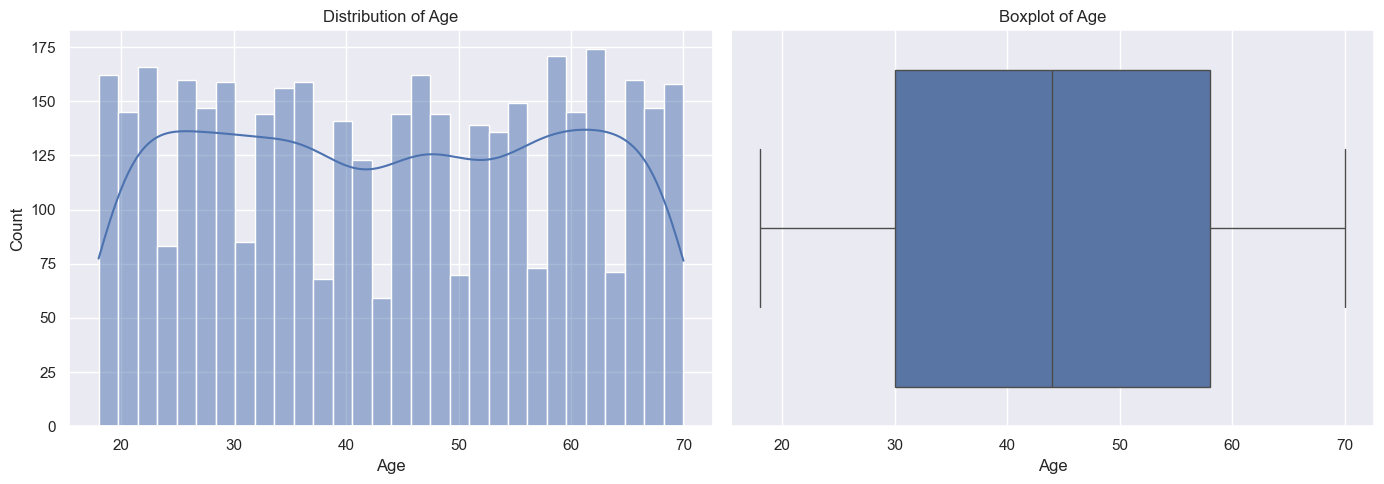

In [23]:
# Distribution: histogram + KDE, and boxplot for outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(X_train['age'], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Age")
axes[0].set_xlabel("Age")

sns.boxplot(x=X_train['age'], ax=axes[1])
axes[1].set_title("Boxplot of Age")
axes[1].set_xlabel("Age")

plt.tight_layout()
plt.show()

In [24]:
# IQR-based outlier check
q1, q3 = X_train['age'].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

outliers = X_train[(X_train['age'] < lower) | (X_train['age'] > upper)]
print(f"IQR bounds: [{lower:.1f}, {upper:.1f}]")
print(f"Number of outliers: {len(outliers)}")

IQR bounds: [-12.0, 100.0]
Number of outliers: 0


#### 🔍 Takeaways: `age`

- **Uniform, not normal:** skewness ≈ 0.01 (symmetric) but kurtosis ≈ -1.25 (platykurtic — flatter and thinner-tailed than a bell curve). Combined with hard bounds at 18 and 70, `age` looks roughly uniformly sampled rather than clustered around a typical customer age.
- **No dominant cohort:** mean (43.7) and median (44) are nearly identical, and the IQR (30–57) spans almost half the full range. There's no age group that stands out as "the typical subscriber."
- **No outliers:** IQR bounds [-10.5, 97.5] comfortably contain the full 18–70 range, so no cleaning or capping is needed.
- **Modeling implication:** a flat marginal distribution means `age` is unlikely to be a strong standalone churn predictor by itself — a bivariate check (e.g., churn rate by age bucket, or `age` split by `churned`) is needed to see if it still carries signal once combined with the target.

#### Univariate analysis: `watch_hours`

In [25]:
# Summary statistics
watch_hours = X_train['watch_hours'].copy()
print(f"Description \n {watch_hours.describe()}")
print(f"Skewness: {watch_hours.skew():.4f}")
print(f"Kurtosis: {watch_hours.kurt():.4f}")

Description 
 count    4000.000000
mean       11.630010
std        12.014596
min         0.010000
25%         3.310000
50%         8.020000
75%        15.970000
max       110.400000
Name: watch_hours, dtype: float64
Skewness: 2.3220
Kurtosis: 8.4123


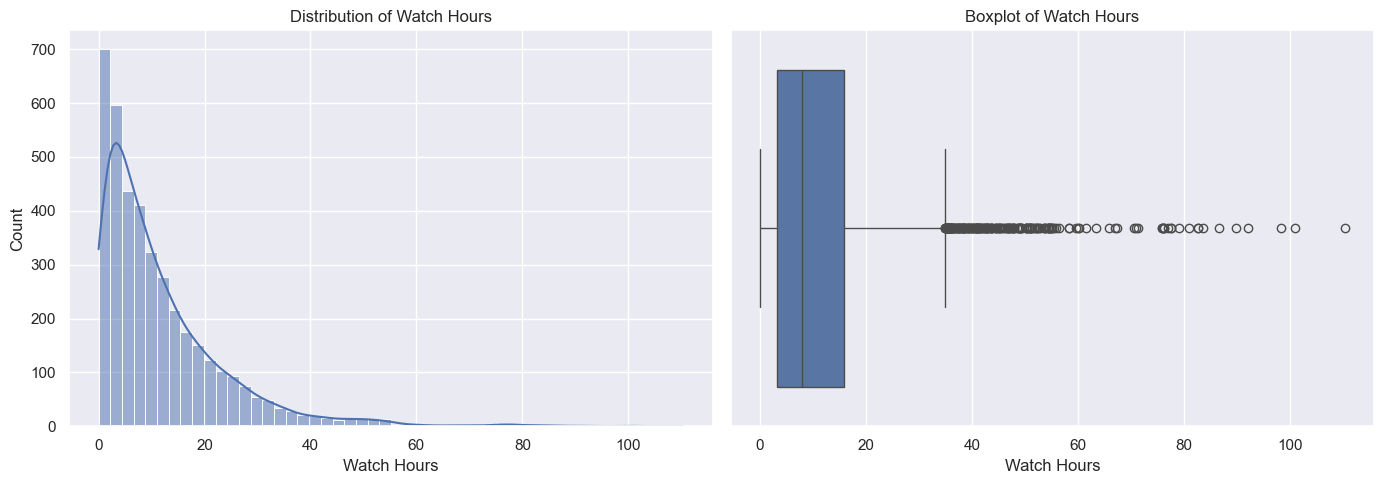

In [46]:
# Distribution: histogram + KDE, and boxplot for outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(watch_hours, bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Watch Hours")
axes[0].set_xlabel("Watch Hours")

sns.boxplot(x=watch_hours, ax=axes[1])
axes[1].set_title("Boxplot of Watch Hours")
axes[1].set_xlabel("Watch Hours")

plt.tight_layout()
plt.show()

In [27]:
# IQR-based outliers check
watch_hours_q1, watch_hours_q3 = watch_hours.quantile([0.25, 0.75])
watch_hours_iqr = watch_hours_q3 - watch_hours_q1
lower, upper = watch_hours_q1 - 1.5 * watch_hours_iqr, watch_hours_q3 + 1.5 * watch_hours_iqr

watch_hours_outliers = watch_hours[(watch_hours < lower) | (watch_hours > upper)]
print(f"IQR bounds: {lower:.1f}, {upper:.1f}")
print(f"Number of outliers: {len(watch_hours_outliers)}")

IQR bounds: -15.7, 35.0
Number of outliers: 191


#### 🔍 Takeaways: `watch_hours`

- **Strongly right-skewed:** skewness ≈ 2.32 and kurtosis ≈ 8.41 — the opposite of `age`'s flat, symmetric shape. Mean (11.63) sits well above the median (8.02), confirming a long right tail.
- **Most users watch moderately, a minority binges:** the IQR (3.31–15.97 hrs) covers the bulk of users, but the max reaches 110.4 hrs — consistent with the histogram's right-skew flagged earlier.
- **Outliers are heavy but plausible:** the IQR rule flags 191 of 4000 training rows (~4.8%) above the upper bound of 35.0 hrs (the lower bound is negative and not meaningful here, since watch hours can't go below 0). These look like genuine high-engagement "binge watcher" behavior rather than data errors, so they're candidates for a distinct segment rather than for removal/capping.
- **Modeling implication:** the skew is why train/test splitting was stratified on quantile bins of `watch_hours` (and `avg_watch_time_per_day`) rather than a plain random split. Tree-based models (Random Forest/XGBoost/LightGBM) can handle this skew natively, but a linear/logistic model would likely benefit from a log-transform given the skewness/kurtosis magnitude.

#### Univariate analysis: `last_login_days`

In [28]:
# Summary statistics
last_login_days = X_train['last_login_days']
print(f"Description \n {last_login_days.describe()}")
print(f"Skewness: {last_login_days.skew():.2f}")
print(f"Kurtosis: {last_login_days.kurt():.2f}")

Description 
 count    4000.000000
mean       30.084250
std        17.614475
min         0.000000
25%        15.000000
50%        30.000000
75%        45.000000
max        60.000000
Name: last_login_days, dtype: float64
Skewness: -0.03
Kurtosis: -1.20


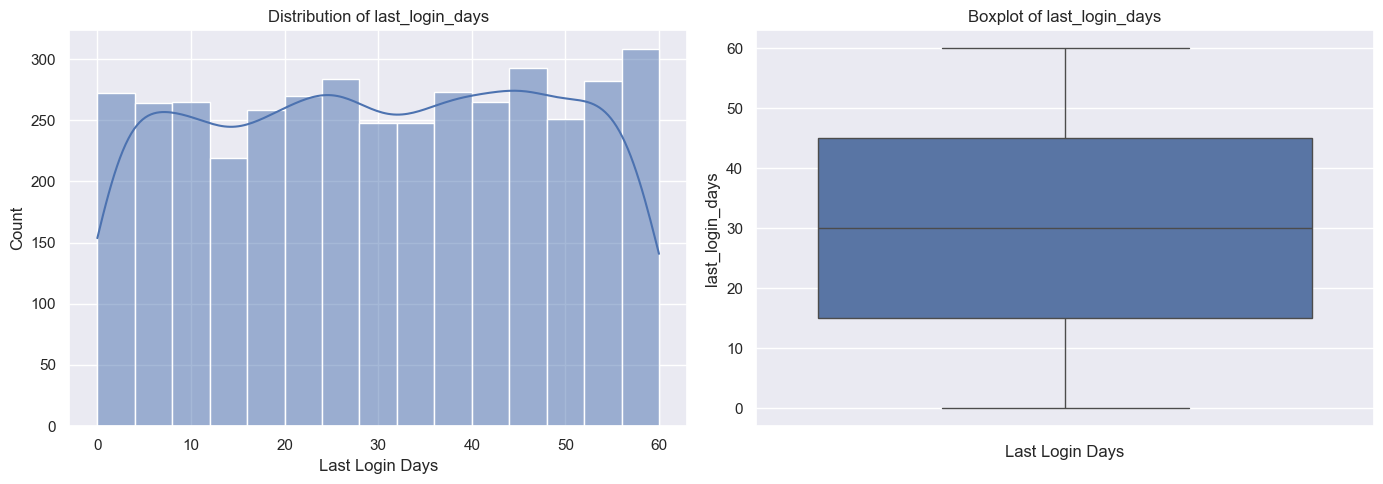

In [29]:
# Distribution: histogram + KDE, and boxplot for outliers
fix, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(last_login_days, bins=15, kde=True, ax=axes[0])
axes[0].set_title("Distribution of last_login_days")
axes[0].set_xlabel("Last Login Days")

sns.boxplot(last_login_days, ax=axes[1])
axes[1].set_title("Boxplot of last_login_days")
axes[1].set_xlabel("Last Login Days")

plt.tight_layout()
plt.show()

In [30]:
# IQR-based outliers check
last_login_days_q1, last_login_days_q3 = last_login_days.quantile([0.25, 0.75])
last_login_days_iqr = last_login_days_q3 - last_login_days_q1
last_login_days_lower, last_login_days_upper = last_login_days_q1 - 1.5 * last_login_days_iqr, last_login_days_q3 + 1.5 * last_login_days_iqr

last_login_days_outlers = last_login_days[(last_login_days < last_login_days_lower) | (last_login_days > last_login_days_upper)]
print(f"IQR Bound: {last_login_days_iqr:.4f}")
print(f"Number of outlers: {len(last_login_days_outlers)}")

IQR Bound: 30.0000
Number of outlers: 0


#### 🔍 Takeaways: `last_login_days`

- **Uniform, not normal:** skewness ≈ -0.03 (symmetric) and kurtosis ≈ -1.20 (platykurtic — flatter and thinner-tailed than a bell curve), nearly the same shape as `age`. Mean (30.08) and median (30) match, and the quartiles fall at exactly 15 / 30 / 45, which is what an even spread over 0–60 days would give.
- **Discrete and hard-bounded:** values are whole days from 0 to 60, with every day holding roughly the same number of users. There's no typical level of login recency; users are spread evenly from "logged in today" to "inactive for 2 months."
- **Histogram edges are artifacts, not signal:** the taller last bar comes from binning (the final bin covers 5 days, 56–60, while the others cover 4), and the KDE dips at 0 and 60 only because the smoothing curve extends past the hard bounds. Neither reflects a real change in the data.
- **No outliers:** IQR bounds [-30, 90] contain the full 0–60 range, so no cleaning or capping is needed.
- **Modeling implication:** like `age`, the flat distribution tells us nothing about churn by itself. But this feature measures login inactivity directly, which makes it the leading candidate for the *Early Attrition Indicators* question. A bivariate check (churn rate by recency bucket, e.g. 0–7 / 8–14 / 15–30 / 31–45 / 46–60 days) is needed to see whether churn rises with inactivity. If it rises in a sharp step rather than a straight line, a threshold flag or bucketed version may serve a linear/logistic model better than the raw value; tree-based models will find the split on their own.


#### Univariate analysis: `number_of_profiles`

In [31]:
# Summary statistics
number_of_profiles = X_train['number_of_profiles']
print(f"Description \n {number_of_profiles.describe()}")
print(f"Skewness: {number_of_profiles.skew():.2f}")
print(f"Kurtosis: {number_of_profiles.kurt():.2f}")

Description 
 count    4000.000000
mean        3.030500
std         1.411938
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: number_of_profiles, dtype: float64
Skewness: -0.02
Kurtosis: -1.30


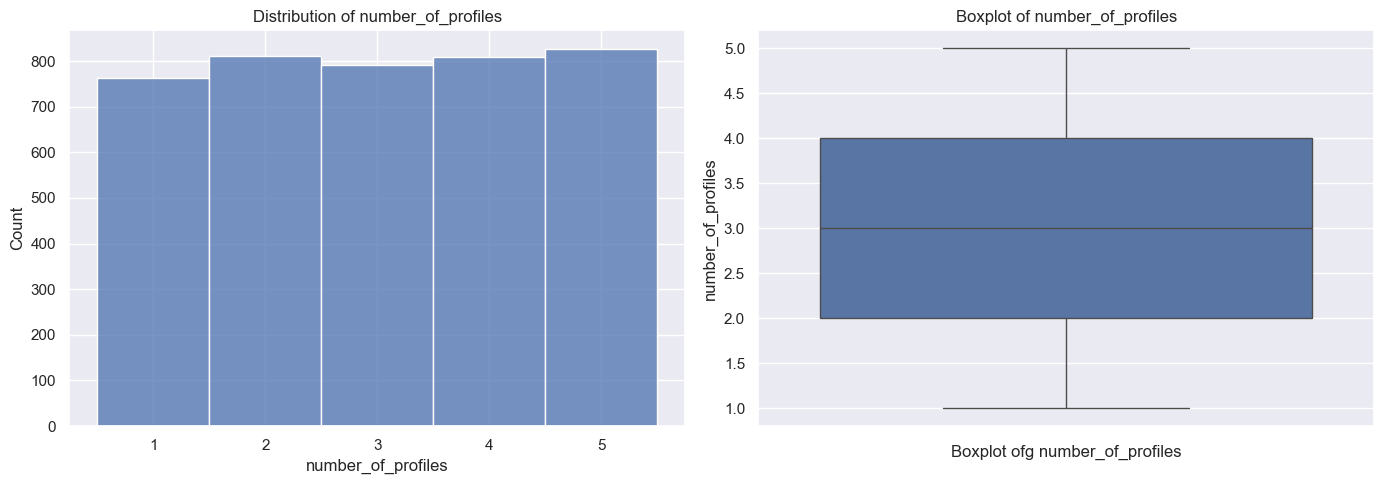

In [41]:
# Distribution: Histogram, boxplot for outlier
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(number_of_profiles, discrete=True, bins=5, ax=axes[0])
axes[0].set_title("Distribution of number_of_profiles")
axes[0].set_xlabel("number_of_profiles")

sns.boxplot(number_of_profiles, ax=axes[1])
axes[1].set_title("Boxplot of number_of_profiles")
axes[1].set_xlabel("Boxplot ofg number_of_profiles")

plt.tight_layout()
plt.show()

In [36]:
# IQR-based outliers check
number_of_profiles_q1, number_of_profiles_q3 = number_of_profiles.quantile([0.25, 0.75])
number_of_profiles_iqr = number_of_profiles_q3 - number_of_profiles_q1
number_of_profiles_lower, number_of_profiles_upper = number_of_profiles_q1 - 1.5 * number_of_profiles_iqr, number_of_profiles_q3 + 1.5 * number_of_profiles_iqr

number_of_profiles_outlers = number_of_profiles[(number_of_profiles < number_of_profiles_lower) | (number_of_profiles > number_of_profiles_upper)]
print(f"IQR Bound: {number_of_profiles_iqr}")
print(f"Number of outlers: {len(number_of_profiles_outlers)}")

IQR Bound: 2.0
Number of outlers: 0


In [38]:
number_of_profiles.value_counts()

number_of_profiles
5    826
2    812
4    808
3    791
1    763
Name: count, dtype: int64

#### 🔍 Takeaways: `number_of_profiles`

- **Discrete and uniform:** the feature takes only 5 values (1–5) with near-equal counts (763 / 812 / 791 / 808 / 826). Each level is within ~5% of the 800 expected if they were equal, and a chi-square goodness-of-fit check (χ² ≈ 2.9, df = 4, p ≈ 0.57) finds no meaningful difference from uniform. Skewness ≈ -0.02 and kurtosis ≈ -1.30 confirm the same flat, symmetric shape seen in `age` and `last_login_days`.
- **No typical account size:** accounts are split evenly from single users (1 profile) to five-person households (5 profiles). If profile count stands in for household size or account sharing, no group dominates the customer base.
- **Plot artifacts, not signal:** the wavy KDE with dips at 1.5 / 2.5 / 3.5 / 4.5 comes from drawing a smooth curve over whole-number values that exist only at integers. The bars are also off-center because `bins=5` makes 0.8-wide bins. A `countplot` or `histplot(..., discrete=True)` without KDE is the right view for this feature.
- **No outliers:** IQR bounds [-1, 7] contain the full 1–5 range, so no cleaning or capping is needed. With values limited to 1–5, the boxplot adds little beyond the quartiles (2 / 3 / 4).
- **Modeling implication:** treat it as an ordinal feature and keep it as a single numeric column; no transform or scaling is needed for tree-based models. A bivariate check (churn rate per profile count) is needed to see whether churn changes steadily with the number of profiles, e.g. whether larger households are more committed. If churn differs by level with no steady trend, one-hot encoding may suit a linear/logistic model better.

#### Univariate analysis: `avg_watch_time_per_day`

In [42]:
# Summary statistics
avg_watch_time_per_day = X_train['avg_watch_time_per_day'].copy()
print(f"Description \n {avg_watch_time_per_day.describe()}")
print(f"Skewness: {avg_watch_time_per_day.skew():.4f}")
print(f"Kurtosis: {avg_watch_time_per_day.kurt():.4f}")

Description 
 count    4000.000000
mean        0.891062
std         2.709301
min         0.000000
25%         0.110000
50%         0.290000
75%         0.720000
max        98.420000
Name: avg_watch_time_per_day, dtype: float64
Skewness: 16.5181
Kurtosis: 474.7362


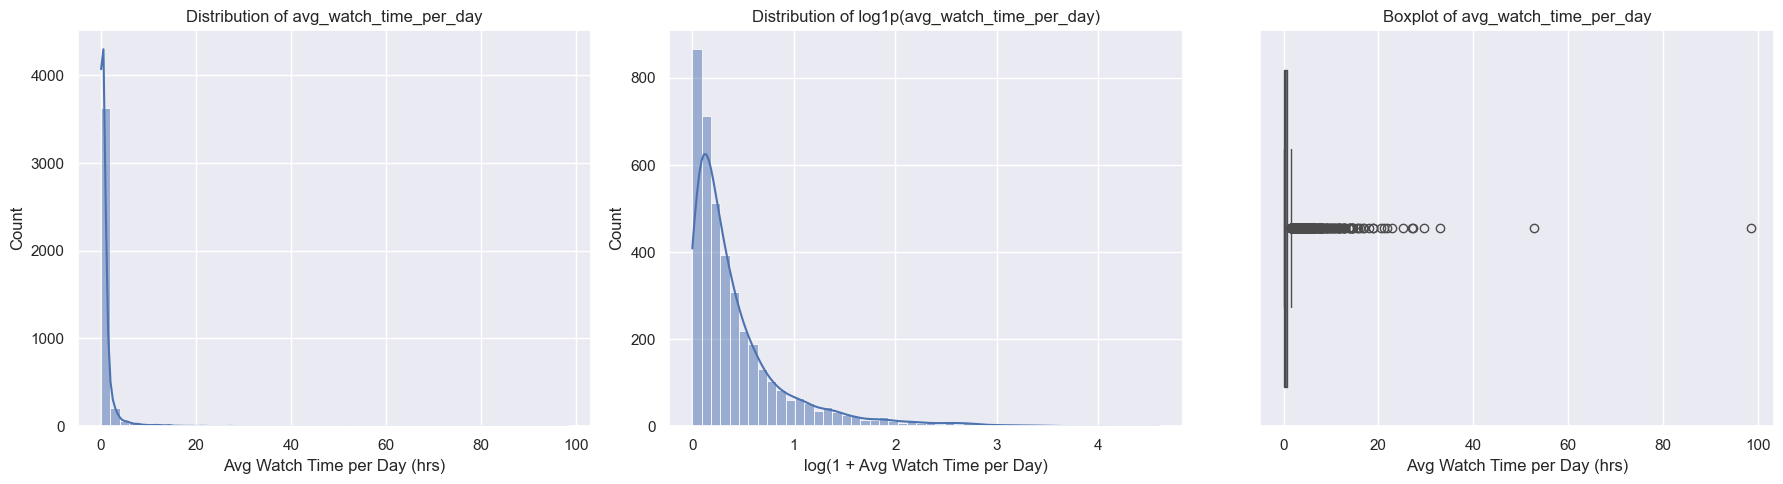

In [43]:
# Distribution: histogram + KDE (raw and log1p), and boxplot for outliers
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(avg_watch_time_per_day, bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribution of avg_watch_time_per_day")
axes[0].set_xlabel("Avg Watch Time per Day (hrs)")

sns.histplot(np.log1p(avg_watch_time_per_day), bins=50, kde=True, ax=axes[1])
axes[1].set_title("Distribution of log1p(avg_watch_time_per_day)")
axes[1].set_xlabel("log(1 + Avg Watch Time per Day)")

sns.boxplot(x=avg_watch_time_per_day, ax=axes[2])
axes[2].set_title("Boxplot of avg_watch_time_per_day")
axes[2].set_xlabel("Avg Watch Time per Day (hrs)")

plt.tight_layout()
plt.show()

In [44]:
# IQR-based outliers check
avg_watch_time_per_day_q1, avg_watch_time_per_day_q3 = avg_watch_time_per_day.quantile([0.25, 0.75])
avg_watch_time_per_day_iqr = avg_watch_time_per_day_q3 - avg_watch_time_per_day_q1
avg_watch_time_per_day_lower, avg_watch_time_per_day_upper = avg_watch_time_per_day_q1 - 1.5 * avg_watch_time_per_day_iqr, avg_watch_time_per_day_q3 + 1.5 * avg_watch_time_per_day_iqr

avg_watch_time_per_day_outliers = avg_watch_time_per_day[(avg_watch_time_per_day < avg_watch_time_per_day_lower) | (avg_watch_time_per_day > avg_watch_time_per_day_upper)]
print(f"IQR bounds: [{avg_watch_time_per_day_lower:.1f}, {avg_watch_time_per_day_upper:.1f}]")
print(f"Number of outliers: {len(avg_watch_time_per_day_outliers)} ({len(avg_watch_time_per_day_outliers) / len(avg_watch_time_per_day):.1%})")

IQR bounds: [-0.8, 1.6]
Number of outliers: 449 (11.2%)


In [45]:
# Is it derived from other columns? Check against watch_hours / (last_login_days + 1)
derived = (X_train['watch_hours'] / (X_train['last_login_days'] + 1)).round(2)
print(f"Rows matching watch_hours / (last_login_days + 1): {np.isclose(derived, avg_watch_time_per_day, atol=0.01).mean():.2%}")

# Rank correlation with the two source features
print(X_train[['avg_watch_time_per_day', 'watch_hours', 'last_login_days']].corr(method='spearman').round(2))

# Values impossible as a real daily average (> 24 hrs/day), and exact zeros
print(f"\nRows above 24 hrs/day: {(avg_watch_time_per_day > 24).sum()}")
print(f"Rows equal to 0: {(avg_watch_time_per_day == 0).sum()}")
print(f"Skewness after log1p: {np.log1p(avg_watch_time_per_day).skew():.4f}")

Rows matching watch_hours / (last_login_days + 1): 100.00%
                        avg_watch_time_per_day  watch_hours  last_login_days
avg_watch_time_per_day                    1.00         0.79            -0.53
watch_hours                               0.79         1.00             0.00
last_login_days                          -0.53         0.00             1.00

Rows above 24 hrs/day: 7
Rows equal to 0: 40
Skewness after log1p: 2.4998


#### 🔍 Takeaways: `avg_watch_time_per_day`

- **Extremely right-skewed:** skewness ≈ 16.52 and kurtosis ≈ 474.7, far beyond `watch_hours` (2.32 / 8.41). The mean (0.89) is about 3× the median (0.29), and 75% of users are at or below 0.72 hrs/day, yet the max reaches 98.42.
- **It's a calculated column, not an independent measurement:** every training row matches `watch_hours / (last_login_days + 1)` to 2 decimals (the `+ 1` avoids dividing by zero for users who logged in today). It has a rank correlation of 0.79 with `watch_hours` and -0.53 with `last_login_days`, while those two are uncorrelated (0.00), so this column combines two features we already have.
- **The "per day" label is misleading:** 7 training rows exceed 24 hrs/day (max 98.42), which is impossible as a real daily average. All of them have `last_login_days` of 0 or 1, so the full `watch_hours` total is divided by only 1 or 2. The extreme tail comes from the formula, not from binge watchers. At the other end, 40 rows are exactly 0.00: small `watch_hours` (≤ 0.29) divided by long inactivity (≥ 7 days) rounds to zero.
- **Outliers come from the formula:** IQR bounds [-0.8, 1.6] flag 449 of 4000 training rows (~11.2%), more than twice the rate of `watch_hours` (4.8%). Most are users who logged in recently, so removing or capping them would skew the data toward inactive users. They should be kept.
- **A log transform helps but doesn't fix it:** `log1p` cuts skewness from 16.5 to about 2.5. The middle plot shows a readable shape, but it's still right-skewed.
- **Modeling implication:** since it's calculated from `watch_hours` and `last_login_days`, it adds a ratio, not new information. Tree-based models can use it as-is, but a linear/logistic model would need `log1p` and would face collinearity with the two features it comes from. During feature selection, decide whether to keep the ratio, the two original features, or both. In the bivariate step, compare its churn signal with `last_login_days` alone, since much of it may simply be login recency.

#### Univariate analysis: `gender`

In [58]:
# Summary statistics: counts and proportions per category
gender = X_train['gender']
print(f"Unique values: {gender.unique()}")

gender_summary = pd.DataFrame({
    'count': gender.value_counts(),
    'proportion %': gender.value_counts(normalize=True).round(4) * 100
})
print(f"\n{gender_summary}")

Unique values: ['Male' 'Female' 'Other']

        count  proportion %
gender                     
Female   1392         34.80
Male     1314         32.85
Other    1294         32.35


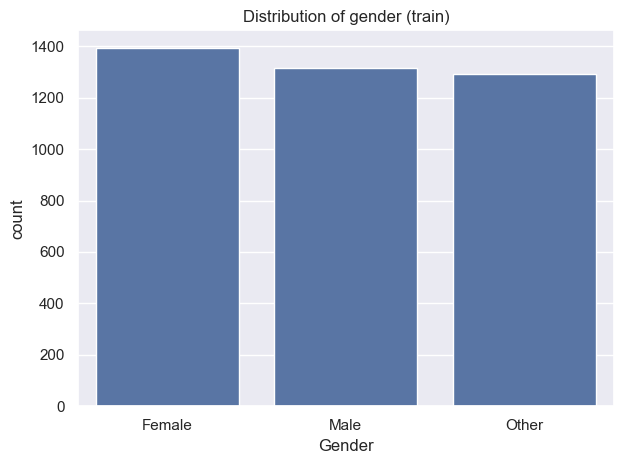

In [ ]:
# Distribution: countplot
order = gender.value_counts().index
sns.countplot(x=gender, order=order)
plt.title("Distribution of gender (train)")
plt.xlabel("Gender")

plt.tight_layout()
plt.show()

#### 🔍 Takeaways: `gender`

- **Nominal, 3 clean categories:** `Female`, `Male`, `Other`, with no missing values and no typos or variant spellings to merge. There's no natural order, so the numeric-feature checks used above (skewness, kurtosis, IQR outliers) don't apply here.
- **`Other` is unusually large:** almost a third of users are `Other`, far more than a real subscriber base would normally report. Together with the uniform shape of most features, this suggests the data is synthetic or sampled evenly on purpose. Keep this in mind before turning any gender finding into a business recommendation.
- **Modeling implication:** with 3 unordered levels, use one-hot encoding (drop one level for a linear/logistic model to avoid collinearity). Tree-based models like CatBoost/LightGBM can take it as a categorical directly.

#### Univariate analysis: `subscription_type`

In [60]:
# Summary statistics
subscription_type = X_train['subscription_type']
print(f"Unique Values: {subscription_type.unique()}")

subscription_type_summary = pd.DataFrame({
  'count': subscription_type.value_counts(),
  'proportion %': subscription_type.value_counts(normalize=True).round(4) * 100
})
print(f"{subscription_type_summary}")

Unique Values: ['Standard' 'Premium' 'Basic']
                   count  proportion %
subscription_type                     
Premium             1355         33.88
Basic               1323         33.08
Standard            1322         33.05


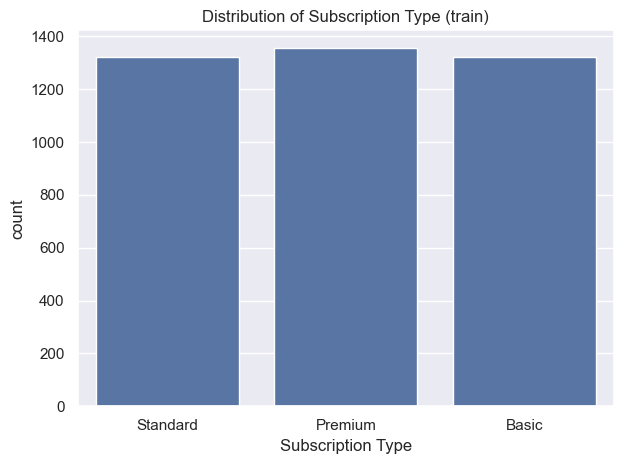

In [63]:
# Distribution: countplot
sns.countplot(x=subscription_type)
plt.title("Distribution of Subscription Type (train)")
plt.xlabel("Subscription Type")

plt.tight_layout()
plt.show()

#### 🔍 Takeaways: `subscription_type`

- **Distribution:** Pretty much an even three-way split: `34%` Premium, `33%` Standard, `33%` Basic. No tier dominates, so there's no class imbalance to worry about here.
- **Natural order:** The tiers have a clear ranking (Basic < Standard < Premium), mostly by price and features.
- **Modeling implication:** Ordinal encoding (Basic=0, Standard=1, Premium=2) makes sense since there's a real order. Tree-based models will handle it fine. For linear models, keep in mind that ordinal encoding assumes the gaps between tiers are equal. If that looks off, one-hot encoding is a safe fallback with only 3 levels.


#### Univariate analysis: `region`

In [64]:
# Summary statistics
region = X_train['region']
print(f"Unique value {region.unique()}")

region_summary = pd.DataFrame({
  'count': region.value_counts(),
  'proportion %': region.value_counts(normalize=True).round(4) * 100
})
print(f"{region_summary}")

Unique value ['South America' 'North America' 'Oceania' 'Europe' 'Asia' 'Africa']
               count  proportion %
region                            
South America    707         17.68
North America    693         17.32
Europe           686         17.15
Asia             673         16.82
Africa           635         15.88
Oceania          606         15.15


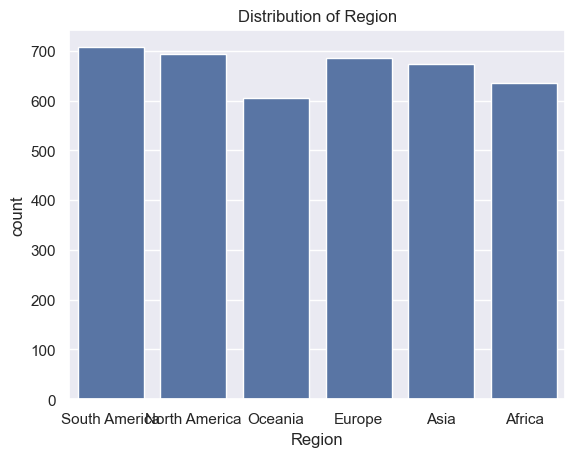

In [66]:
# Distribution: countplot
sns.countplot(x=region)
plt.title("Distribution of Region")
plt.xlabel("Region")
plt.show()

#### 🔍 Takeaways: `region`

- **Distribution:** Very even. Each of the 6 categories sits at about 16–17%, so no category is rare and none dominates.
- **No natural order:** The categories don't rank against each other, so ordinal encoding would add a fake ordering.
- **Modeling implication:** One-hot encoding is the way to go. 6 categories only adds 5–6 columns, which is no problem.
- **Worth checking:** A flat split like this doesn't tell us anything about churn yet. We'll look at churn rate by category in the bivariate step. If churn is roughly the same across all of them, this feature probably won't help the model much.


#### Univariate analysis: `device`

In [67]:
# Summary statistics
device = X_train['device']
print(f"Unique Values: {device.unique()}")

device_summary = pd.DataFrame({
  'count': device.value_counts(),
  'proportion %': device.value_counts(normalize=True).round(4) * 100
})
print(f"{device_summary}")

Unique Values: ['Desktop' 'Tablet' 'TV' 'Mobile' 'Laptop']
         count  proportion %
device                      
Tablet     843         21.08
Mobile     805         20.13
Laptop     805         20.13
TV         798         19.95
Desktop    749         18.72


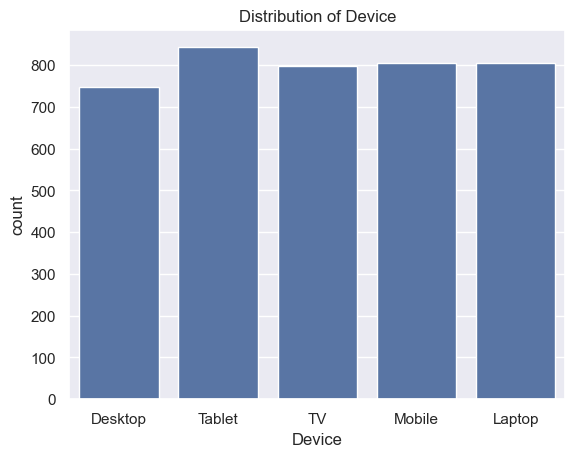

In [68]:
# Distribution: countplot
sns.countplot(x=device)
plt.title("Distribution of Device")
plt.xlabel("Device")
plt.show()

#### 🔍 Takeaways: `device`

- **Distribution:** Nearly even across all 5 devices, about 20% each. No device is rare or dominant.
- **No natural order:** A TV isn't "more" than a laptop, so these are plain categories with no ranking.
- **Modeling implication:** Use one-hot encoding. With only 5 categories, that adds just a few columns.
- **Worth checking:** An even split alone doesn't say anything about churn. We'll compare churn rate by device in the bivariate step to see if this feature actually matters.

#### Univariate analysis: `payment_method`

In [69]:
# Summary statistics
payment_method = X_train['payment_method']
print(f"Unique Value: {payment_method.unique()}")

payment_method_summary = pd.DataFrame({
  'count': payment_method.value_counts(),
  'proportion %': payment_method.value_counts(normalize=True).round(4) * 100
})
print(f"{payment_method_summary}")

Unique Value: ['Debit Card' 'Gift Card' 'Crypto' 'PayPal' 'Credit Card']
                count  proportion %
payment_method                     
PayPal            835         20.88
Crypto            820         20.50
Debit Card        811         20.28
Gift Card         773         19.32
Credit Card       761         19.02


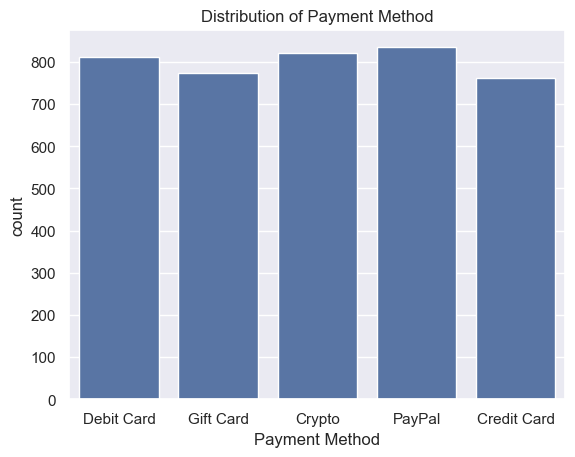

In [70]:
# Distribution: countplot
sns.countplot(x=payment_method)
plt.title("Distribution of Payment Method")
plt.xlabel("Payment Method")
plt.show()

#### 🔍 Takeaways: `payment_method`

- **Distribution:** Pretty even across all 5 methods, about 20% each. No method is rare or dominant.
- **No natural order:** Payment methods don't rank against each other, so these are plain categories.
- **Modeling implication:** Use one-hot encoding. 5 categories only adds a few columns.
- **Worth checking:** In the bivariate step, compare churn rate by method. Methods that don't auto-renew, like gift cards, could show higher churn than cards or PayPal. The data may say otherwise.

#### Univariate analysis: `favorite_genre`

In [71]:
# Summary statistics
favorite_genre = X_train['favorite_genre']
print(f"Unique Values: {favorite_genre.unique()}")

favorite_genre_summary = pd.DataFrame({
  'counts': favorite_genre.value_counts(),
  'proportion %': favorite_genre.value_counts(normalize=True).round(4) * 100
})
print(f"{favorite_genre_summary}")

Unique Values: ['Horror' 'Documentary' 'Action' 'Drama' 'Romance' 'Comedy' 'Sci-Fi']
                counts  proportion %
favorite_genre                      
Documentary        597         14.92
Drama              593         14.82
Action             572         14.30
Horror             570         14.25
Romance            570         14.25
Sci-Fi             564         14.10
Comedy             534         13.35


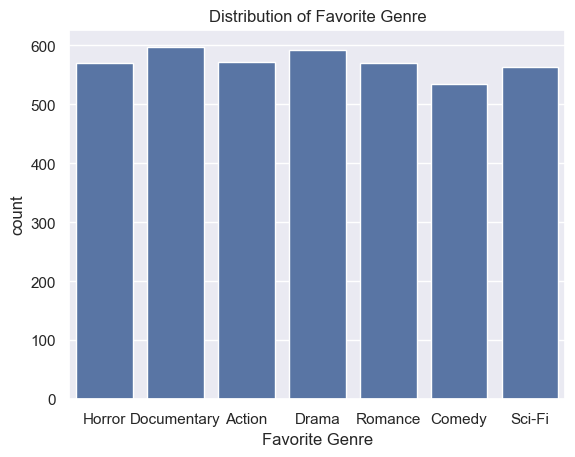

In [72]:
# Distribution: countplot
sns.countplot(x=favorite_genre)
plt.title("Distribution of Favorite Genre")
plt.xlabel("Favorite Genre")
plt.show()

#### 🔍 Takeaways: `favorite_genre`
- **Distribution:** 7 classes distributed evenly
- **No Natural Order:** Unordered classes
- **Modeling implication:** Use one-host encoding

#### 🔍 Takeaways: `favorite_genre`

- **Distribution:** Pretty even across all 7 genres, about 14% each. No genre is rare or dominant.
- **No natural order:** Genres don't rank against each other. Drama isn't "more" than Comedy.
- **Modeling implication:** Use one-hot encoding. 7 categories means about 6–7 extra columns, which is still fine.
- **Worth checking:** In the bivariate step, compare churn rate by genre. Fans of niche genres might churn more if the catalog is thinner there. If churn looks flat across genres, this feature probably won't add much.